# **EDA**

In [7]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import os

### **Cargar Dataset Maestro**

In [8]:
PROCESSED_DATA_PATH = os.path.join('..', 'data', '03_processed')
MASTER_FILE = os.path.join(PROCESSED_DATA_PATH, 'master_dataset_cali.parquet')

df_master = pd.read_parquet(MASTER_FILE)
df_master.info()
df_master.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2016-01-04 to 2022-12-26
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   casos_dengue          365 non-null    int64  
 1   temp_media_semanal    365 non-null    float64
 2   precip_total_semanal  365 non-null    float64
 3   poblacion             365 non-null    int64  
 4   tasa_incidencia_100k  365 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 17.1 KB


,casos_dengue,temp_media_semanal,precip_total_semanal,poblacion,tasa_incidencia_100k
fecha,,,,,
2016-01-04,401,21.950000,14.1,2283846,17.558102
2016-01-11,475,21.514286,122.3,2283846,20.798250
2016-01-18,533,21.414286,20.5,2283846,23.337826
2016-01-25,628,21.685714,55.7,2283846,27.497476
2016-02-01,734,21.214286,39.5,2283846,32.138769


### **Serie de tiempo de casos de Dengue**
- ¿Cómo se han comportado los casos de Dengue a lo largo del tiempo?

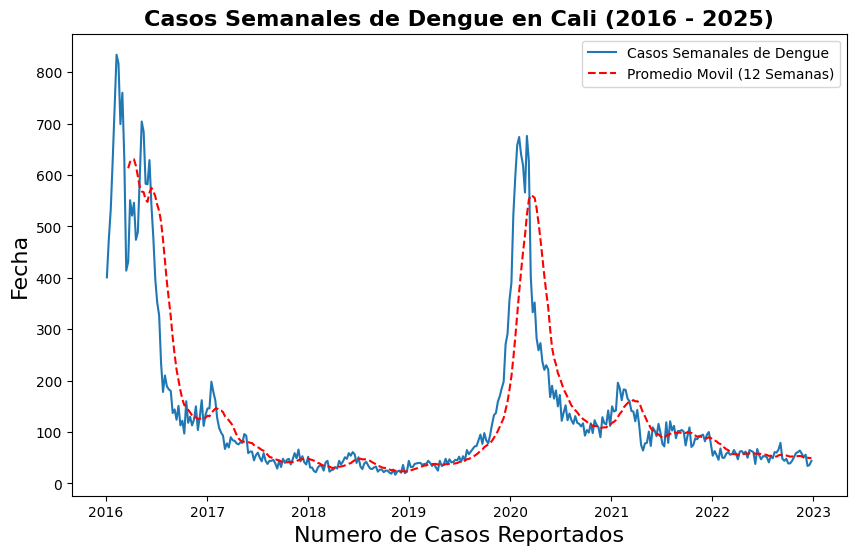

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_master.index,
    df_master['casos_dengue'],
    label='Casos Semanales de Dengue'
)

# Añadir un Promedio Móvil - 'window=12' = un promedio móvil de 12 semanas (aprox. 3 meses)
# Esto suaviza la línea y nos permite ver la "tendencia" subyacente
df_master['casos_promedio_movil_12sem'] = df_master['casos_dengue'].rolling(window=12).mean()

plt.plot(
    df_master.index,
    df_master['casos_promedio_movil_12sem'],
    color='red',
    linestyle='--',
    label='Promedio Movil (12 Semanas)'
)

plt.title('Casos Semanales de Dengue en Cali (2016 - 2025)', fontsize=16, fontweight='bold')
plt.ylabel('Fecha', fontsize=16)
plt.xlabel('Numero de Casos Reportados', fontsize=16)
plt.legend()
plt.show()

**Conclusión**

**El Dengue es Cíclico: No es un problema constante. Funciona en "oleadas". Vemos claramente los "picos" (brotes epidémicos) y los "valles" (períodos inter-epidémicos).**

- Vemos un pico masivo en 2016.

- Vemos un período de calma en 2017-2018.

- Vemos la epidemia más grande de todas en 2019-2020.

### **¿Qué causa esos picos?**

Nuestra hipótesis es el clima. El ciclo de vida del mosquito depende de la lluvia y la temperatura.

Pero no es una relación instantánea. La lluvia de esta semana no causa el pico de dengue de esta semana. Causa el pico de dengue de 4 semanas en el futuro (charcos -> larvas -> mosquitos -> picaduras -> hospital).

**El mosquito (Aedes aegypti) tiene un ciclo de vida que depende del clima pasado:**

* La lluvia de hoy no crea un caso de dengue mañana.
* La lluvia de hoy crea charcos.
* Esos charcos crían larvas durante 1-2 semanas.
* El mosquito adulto emerge, se infecta y pica a un humano (1-2 semanas más).
* El humano se enferma y va al hospital (1 semana después).

**El "retraso" (lag) total es de 2 a 4 semanas**

In [10]:
# Crear la Variable Clave: "El Lag"
# Queremos ver si la lluvia de hace 4 SEMANAS puede predecir los casos de dengue de HOY.

# .shift(4) es un comando de Pandas que "desplaza" la columna 4 filas (semanas) hacia el futuro.
df_master['precip_lag_4_semanas'] = df_master['precip_total_semanal'].shift(4)

# Hacemos lo mismo para la temperatura (2 semanas de lag)
df_master['temp_lag_2_semanas'] = df_master['temp_media_semanal'].shift(2)

df_master.head()

,casos_dengue,temp_media_semanal,precip_total_semanal,poblacion,tasa_incidencia_100k,casos_promedio_movil_12sem,precip_lag_4_semanas,temp_lag_2_semanas
fecha,,,,,,,,
2016-01-04,401,21.950000,14.1,2283846,17.558102,NaN,NaN,NaN
2016-01-11,475,21.514286,122.3,2283846,20.798250,NaN,NaN,NaN
2016-01-18,533,21.414286,20.5,2283846,23.337826,NaN,NaN,21.950000
2016-01-25,628,21.685714,55.7,2283846,27.497476,NaN,NaN,21.514286
2016-02-01,734,21.214286,39.5,2283846,32.138769,NaN,14.1,21.414286


### **Visualización de la Correlación**

**Vamos a crear un gráfico con DOS ejes Y:**

- Eje Izquierdo (Azul): Casos de Dengue
- Eje Derecho (Rojo): Lluvia (con el lag)

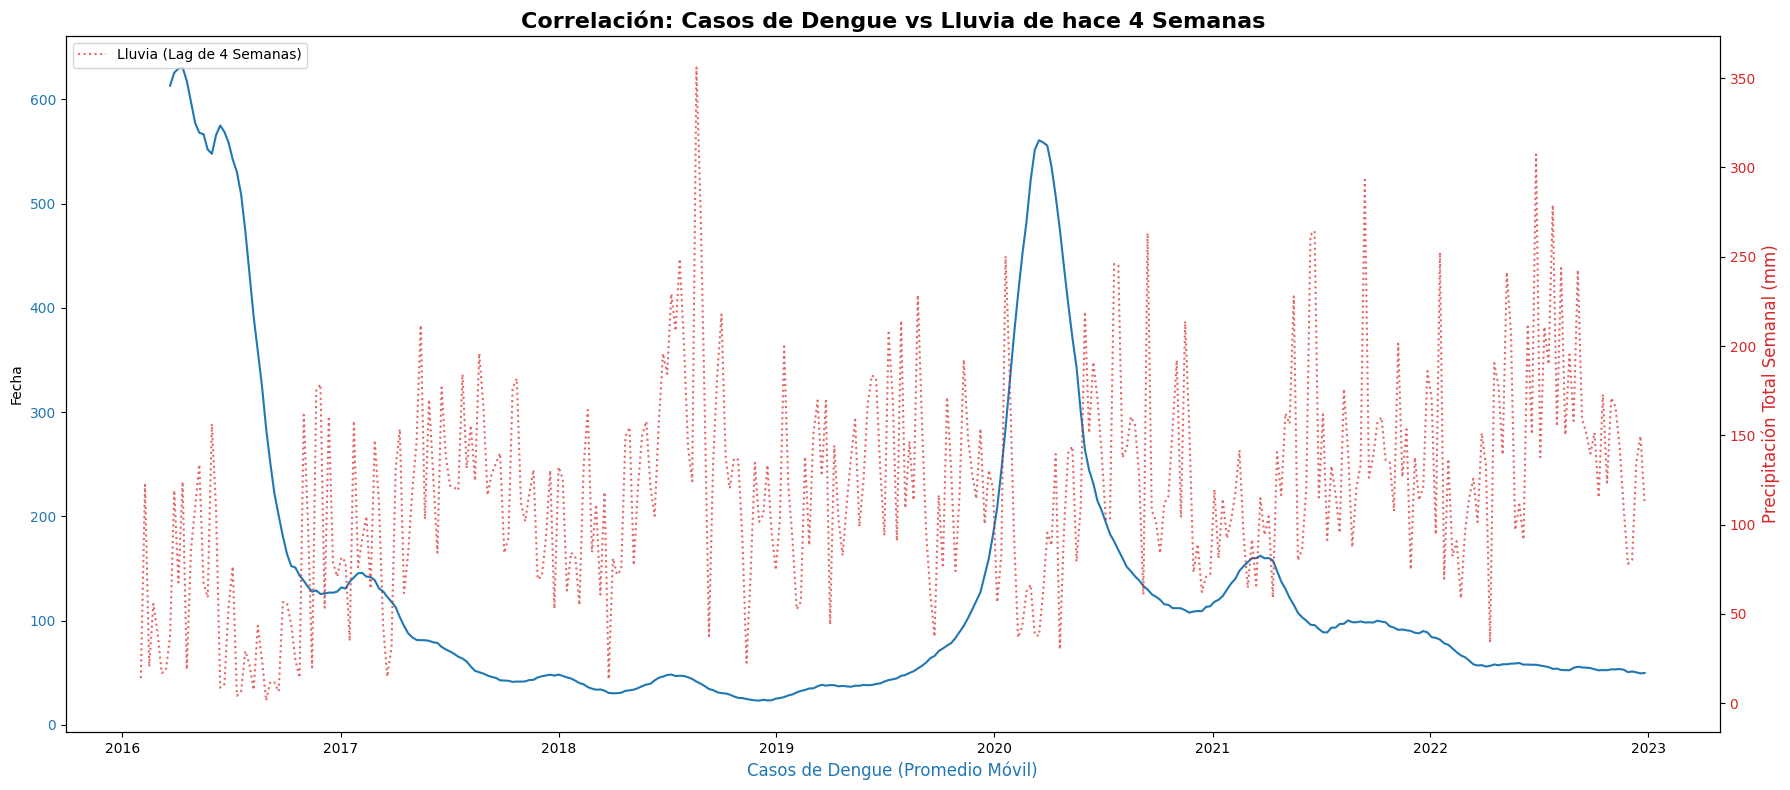

In [11]:
fig, ax1 = plt.subplots(figsize=(18, 8))

# Eje Izquierdo (Casos)
color ='tab:blue'
ax1.set_title('Correlación: Casos de Dengue vs Lluvia de hace 4 Semanas', fontsize=16, fontweight='bold')
ax1.set_ylabel('Fecha')
ax1.set_xlabel('Casos de Dengue (Promedio Móvil)', color=color, fontsize=12)

ax1.plot(
    df_master.index, 
    df_master['casos_promedio_movil_12sem'], 
    color=color, 
    label='Promedio Móvil Casos (12 sem)'
)

ax1.tick_params(axis='y', labelcolor=color)

# Eje Derecho (Lluvia)
ax2 = ax1.twinx() # Crea un segundo eje Y que comparte el mismo eje X
color ='tab:red'
ax2.set_ylabel('Precipitación Total Semanal (mm)', color=color, fontsize=12)
ax2.plot(
    df_master.index,
    df_master['precip_lag_4_semanas'],
    color=color,
    linestyle=':',
    alpha=0.7,
    label='Lluvia (Lag de 4 Semanas)'
)

ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.legend(loc='upper left')
plt.show()

- **Línea Azul (Eje Izquierdo):** Es el promedio móvil de los casos de dengue. Es la tendencia suavizada de los brotes.

- **Línea Roja Punteada (Eje Derecho):** Es la lluvia de hace 4 semanas.

**El Hallazgo Clave: Los picos rojos (lluvia) preceden a los picos azules (dengue)**

- Un gran pico de lluvia (rojo) ocurre, y unas 4-6 semanas después, el pico de casos de dengue (azul) le sigue.

- Esto nos prueba visualmente que la precipitación es un evento centinela o un predictor líder de los brotes.

## **Veredicto: El Mapa de Calor de Correlación**

- Vamos a calcular la correlación de Pearson (1.0 = correlación positiva perfecta, -1.0 = negativa, 0 = sin correlación)

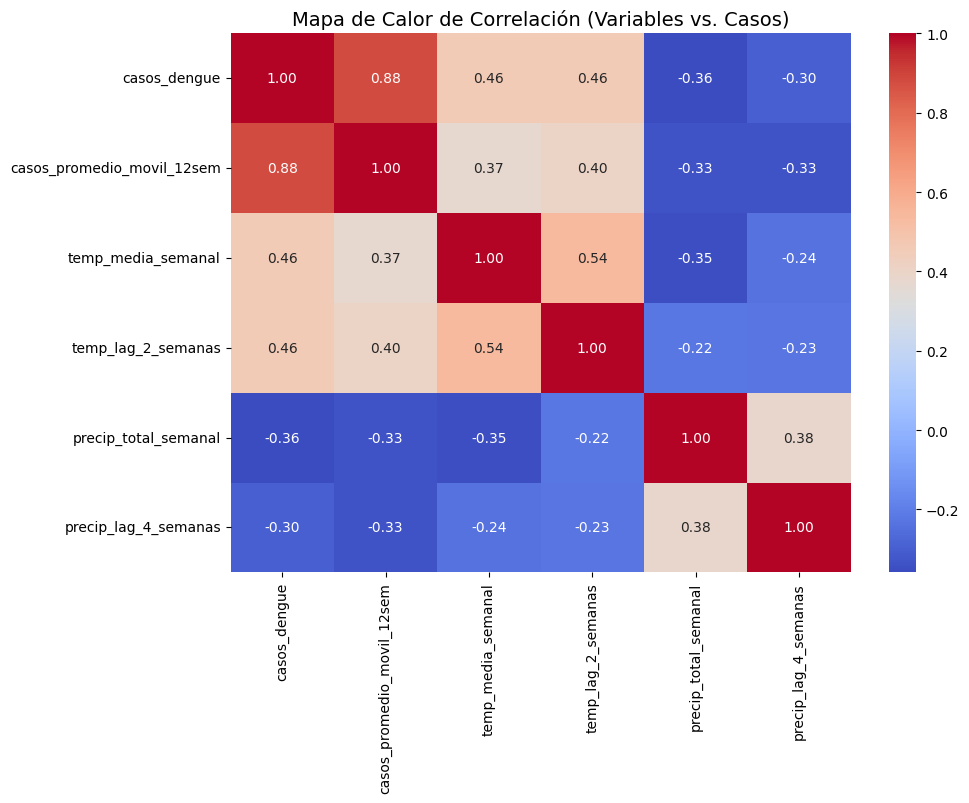

In [12]:
columnas_corr = [
    'casos_dengue', 
    'casos_promedio_movil_12sem',
    'temp_media_semanal',
    'temp_lag_2_semanas', # Nuestra variable
    'precip_total_semanal',
    'precip_lag_4_semanas' # Nuestra variable
]

# Calculamos la Matriz de Correlación
corr_matrix = df_master[columnas_corr].corr()

# Mapa de Calor
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Calor de Correlación (Variables vs. Casos)', fontsize=14)
plt.show()


### **1. casos_promedio_movil_12sem = 0.88**

**Esta es una correlación casi perfecta.**

- Esto es lo que llamamos "autocorrelación". Solo nos dice que los "casos de dengue" están altamente correlacionados con el "promedio de casos de dengue". Es un eco de sí mismo.

- Por qué es Útil: Un valor tan alto (0.88) nos dice que el dengue no es aleatorio. Tiene inercia (momentum). Un brote que empieza una semana tiende a continuar la siguiente. 

### **2. temp_media_semanal = 0.46 (El Acelerador)**

**Una correlación positiva moderada-fuerte.**

- **Biología:** El mosquito Aedes aegypti es de sangre fría. Las temperaturas más altas aceleran su metabolismo.

- **El Resultado:** Se reproducen más rápido, pican con más frecuencia y, lo más importante, el virus del dengue se incuba dentro del mosquito más rápido (lo que se llama "período de incubación extrínseco").

- **Conclusión:** Más calor = mosquitos más rápidos y peligrosos = más dengue. (0.46) lo comprueba.

### **3. precip_total_semanal = -0.36 El Descubrimiento**

**Una correlación negativa moderada**

- Nuestra hipótesis inicial era "más lluvia = más charcos = más dengue". Los datos nos dicen lo contrario: Más lluvia = menos dengue.

- **El "Efecto Lavado" (Flushing Effect)** Un fenómeno epidemiológico real, Un poco de lluvia estancada es malo (cría mosquitos). Pero las lluvias fuertes y sostenidas (como las que mide precip_total_semanal) son buenas, porque lavan y destruyen los criaderos.

- La lluvia fuerte limpia las llantas, materas y canales donde las larvas están creciendo.

**Conclusión: En Cali, las temporadas de alta precipitación en realidad reducen los casos de dengue porque "limpian" la ciudad de larvas**

### **4. precip_lag_4_semanas = -0.30 (La Confirmación)**

**Una correlación negativa, pero ligeramente más débil que la de la lluvia inmediata (-0.36)**

- Tiene Sentido. Esto confirma nuestra teoría del "Efecto Lavado". Nos dice que el impacto de "limpieza" de la lluvia es más fuerte inmediatamente (un -0.36) que 4 semanas después (-0.30).

___
